# Image Classification using MNIST Dataset and K-Nearest Neighbors (KNN)

## Objective
The objective of this project is to perform image classification on handwritten digit images using the MNIST dataset and the K-Nearest Neighbors (KNN) machine learning algorithm.

## Introduction

Image classification is a machine learning task where a model learns to identify and classify images into different categories.

In this project, we use the MNIST dataset, which contains handwritten digit images from 0 to 9. We will train a K-Nearest Neighbors (KNN) classifier to recognize these digits.

In [22]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

The MNIST dataset contains 70,000 handwritten digit images.

Each image:
- Represents a digit from 0 to 9
- Has a size of 28 × 28 pixels
- Is stored as numerical pixel values

In [2]:
#Loading the MNIST Dataset
mnist = fetch_openml('mnist_784', version=1)

In [3]:
print(type(mnist))

<class 'sklearn.utils._bunch.Bunch'>


## Separating Features and Labels

In machine learning:
- Features (`X`) are the input data
- Labels (`y`) are the correct answers

For this dataset:
- `X` contains image pixel values
- `y` contains the digit labels (0–9)

In [4]:
X = mnist.data
y = mnist.target

## Checking Dataset Dimensions

In [5]:
print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (70000, 784)
Label shape: (70000,)


The dataset contains:
- 70,000 images
- 784 features per image
- 10 digit classes

## Visualizing an Image from the Dataset

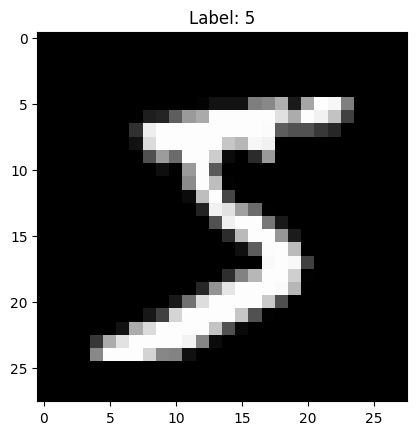

In [6]:
plt.imshow(X.iloc[0].values.reshape(28,28), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

The image is displayed using `matplotlib`.

The original image is stored as 784 pixel values in a single row.  
To display it properly as an image, we reshape it into a 28 × 28 matrix.

## Splitting the Dataset into Training and Testing Data

In machine learning, the dataset is divided into:
- Training data is used to teach the model.  
- Testing data is used to evaluate how well the model performs on unseen data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

Explanation of parameters:

- `test_size=0.2`
  - 20% of the data is used for testing
  - 80% is used for training

- `random_state=42`
  - Ensures reproducible results
  - The dataset split remains the same each time the code runs

In [8]:
print("X_train_shape:", X_train.shape)
print("X_test_shape:", X_test.shape)

print("y_train_shape:", y_train.shape)
print("y_test_shape:", y_test.shape)

X_train_shape: (56000, 784)
X_test_shape: (14000, 784)
y_train_shape: (56000,)
y_test_shape: (14000,)


Interpretation:

- `X_train` contains training images
- `X_test` contains testing images
- `y_train` contains training labels
- `y_test` contains testing labels

## Creating the K-Nearest Neighbors (KNN) Model

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification.

The algorithm works by:
1. Finding the nearest training examples to a new image
2. Checking their labels
3. Predicting the majority label

In [9]:
knn = KNeighborsClassifier(n_neighbors=3)

`n_neighbors=3` means the algorithm checks the 3 nearest images before making a prediction.

The predicted class is determined by majority voting among the nearest neighbors.

## Training the Model

Training is the process where the algorithm learns patterns from the training data and corresponding labels.

In [10]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

KNN is a supervised learning algorithm because it learns using labeled training data.

The model is trained using:
- input images (`X_train`)
- correct labels (`y_train`)

In [11]:
print(knn)

KNeighborsClassifier(n_neighbors=3)


## Making Predictions on Test Data

After training, the model can predict labels for unseen images.

The testing dataset is used to evaluate how accurately the model performs on new data.

In [12]:
y_pred = knn.predict(X_test)

In [13]:
print(y_pred[:10])

['8' '4' '8' '7' '7' '0' '6' '2' '7' '4']


In [14]:
print("Predicted labels:", y_pred[:10])
print("Actual labels:   ", y_test[:10].values)

Predicted labels: ['8' '4' '8' '7' '7' '0' '6' '2' '7' '4']
Actual labels:    ['8', '4', '8', '7', '7', '0', '6', '2', '7', '4']
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']


The predicted labels are compared with the actual labels to evaluate the performance of the model.
Matching values indicate correct predictions.

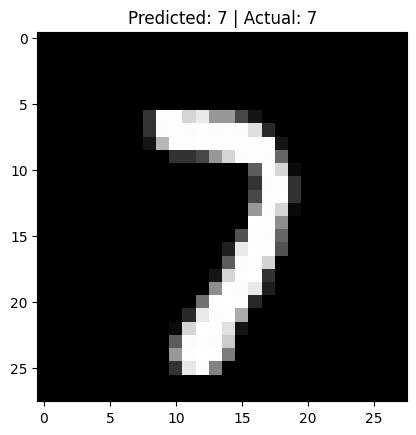

In [20]:
plt.imshow(X_test.iloc[3].values.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {y_pred[3]} | Actual: {y_test.iloc[3]}")
plt.show()

## Evaluating Model Accuracy

Accuracy is used to measure how many predictions made by the model are correct.

It is calculated by comparing the predicted labels with the actual labels.

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 97.13%


The model achieved high accuracy on the test dataset, indicating that the KNN classifier performs well for handwritten digit recognition.

## Classification Report

The classification report provides detailed evaluation metrics for the model, including:

- Precision measures how many predicted labels were correct.
- Recall measures how many actual labels were correctly identified.
- F1-score provides a balanced measure of precision and recall.

These metrics help measure the quality of the classification model.

In [18]:
from sklearn.metrics import classification_report

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1343
           1       0.96      0.99      0.98      1600
           2       0.97      0.97      0.97      1380
           3       0.97      0.96      0.97      1433
           4       0.97      0.96      0.97      1295
           5       0.98      0.97      0.97      1273
           6       0.98      0.99      0.99      1396
           7       0.97      0.98      0.97      1503
           8       0.99      0.94      0.96      1357
           9       0.96      0.95      0.96      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



The classification report shows that the KNN model performs very well across all digit classes.

High precision, recall, and F1-score values indicate strong classification performance on the MNIST dataset.

### Final Result

The KNN classifier successfully classified handwritten digit images from the MNIST dataset with high accuracy.

## Conclusion

In this project, image classification was successfully performed using the MNIST dataset and the K-Nearest Neighbors (KNN) algorithm.

The model was trained on handwritten digit images and achieved high accuracy on the test dataset. This project demonstrates the basic workflow of machine learning for image classification tasks.